<a href="https://colab.research.google.com/github/springboardmentor1234r/B13-AirFly-Insights-Internship/blob/Devika_S_Nair/milestone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AirFly Insights - Milestone 2
Univariate, Bivariate & Delay Analysis

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [5]:
#Load Dataset

df = pd.read_csv('data/Flight_Dataset.csv')
print("Dataset Loaded Successfully")
print("Columns in dataset:\n", df.columns)

Dataset Loaded Successfully
Columns in dataset:
 Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='str')


In [7]:
#FEATURE ENGINEERING (IMPORTANT FIX)

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# Create missing columns safely
df['YEAR'] = df['FL_DATE'].dt.year
df['MONTH'] = df['FL_DATE'].dt.month
df['MONTH_NAME'] = df['FL_DATE'].dt.month_name()
df['WEEKDAY'] = df['FL_DATE'].dt.day_name()

# Extract departure hour safely
df['DEP_HOUR'] = (df['CRS_DEP_TIME'] // 100).astype('Int64')

# Create ROUTE column if missing
if 'ROUTE' not in df.columns:
    df['ROUTE'] = df['ORIGIN'] + "-" + df['DEST']

print("Feature Engineering Completed")

Feature Engineering Completed


In [9]:
#DATA TYPE OPTIMIZATION (SAFE VERSION)

def use_datatypes(df):

    df['CANCELLED'] = df['CANCELLED'].astype('int8')
    df['DIVERTED'] = df['DIVERTED'].astype('int8')

    catg_col = ['AIRLINE','AIRLINE_DOT','AIRLINE_CODE',
                'ORIGIN','ORIGIN_CITY','DEST','DEST_CITY',
                'CANCELLATION_CODE','MONTH_NAME','WEEKDAY','ROUTE']

    for col in catg_col:
        if col in df.columns:
            df[col] = df[col].astype('category')

    float_cols = ['DEP_DELAY','ARR_DELAY','TAXI_IN','TAXI_OUT',
                  'CRS_ELAPSED_TIME','ELAPSED_TIME','AIR_TIME',
                  'DELAY_DUE_CARRIER','DELAY_DUE_WEATHER',
                  'DELAY_DUE_NAS','DELAY_DUE_SECURITY',
                  'DELAY_DUE_LATE_AIRCRAFT','DISTANCE']

    for col in float_cols:
        if col in df.columns:
            df[col] = df[col].astype('float32')

    int_cols = ['DOT_CODE','FL_NUMBER','YEAR','MONTH']

    for col in int_cols:
        if col in df.columns:
            df[col] = df[col].astype('int32')

    if 'DEP_HOUR' in df.columns:
        df['DEP_HOUR'] = df['DEP_HOUR'].astype('Int8')

    return df

df = use_datatypes(df)

print("Memory Optimization Done")
print(df.info())


Memory Optimization Done
<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 38 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[us]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int32         
 5   FL_NUMBER                int32         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             int64         
 11  DEP_TIME                 float64       
 12  DEP_DELAY                float32       
 13  TAXI_OUT                 float32       
 14  WHEELS_OFF               float64       
 15  WHEELS_ON                float64       
 16  TAXI_IN                  float32       
 17  CRS_ARR_TIME 

In [11]:
#ACTIVE FLIGHTS FILTER

active_flights = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)]

print("Active Flights Count:", len(active_flights))

Active Flights Count: 2913804


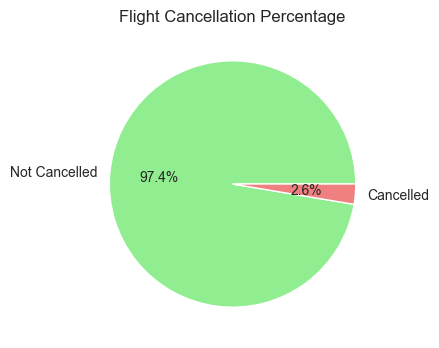

In [12]:
#Cancellation Analysis

plt.figure(figsize=(6,4))
df['CANCELLED'].value_counts().plot.pie(
    labels=['Not Cancelled','Cancelled'],
    autopct='%1.1f%%',
    colors=['lightgreen','lightcoral']
)
plt.title("Flight Cancellation Percentage")
plt.show()


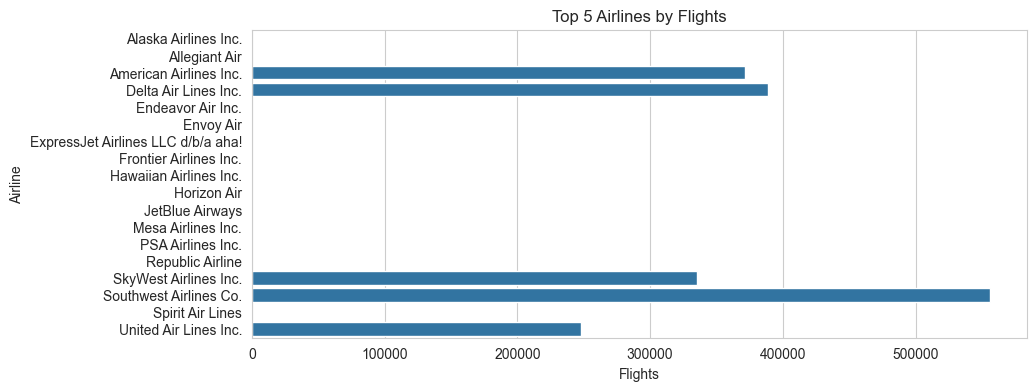

In [13]:
#Top Airlines

top_airlines = active_flights['AIRLINE'].value_counts().head(5)

plt.figure(figsize=(10,4))
sns.barplot(x=top_airlines.values, y=top_airlines.index)
plt.title("Top 5 Airlines by Flights")
plt.xlabel("Flights")
plt.ylabel("Airline")
plt.show()

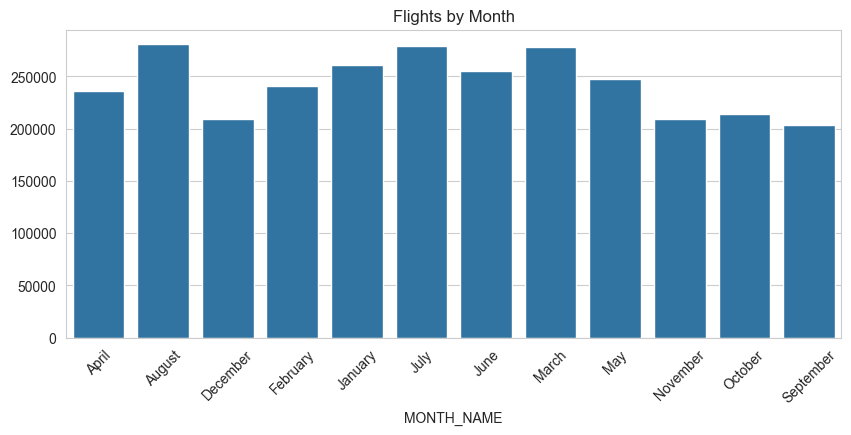

In [14]:
#Busiest Months

month_counts = active_flights['MONTH_NAME'].value_counts()

plt.figure(figsize=(10,4))
sns.barplot(x=month_counts.index, y=month_counts.values)
plt.xticks(rotation=45)
plt.title("Flights by Month")
plt.show()

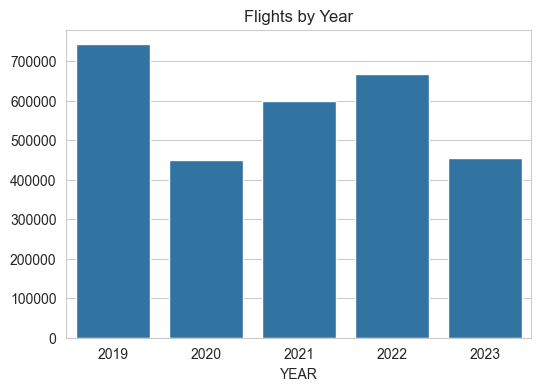

In [15]:
#Flights by Year

year_counts = active_flights['YEAR'].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title("Flights by Year")
plt.show()

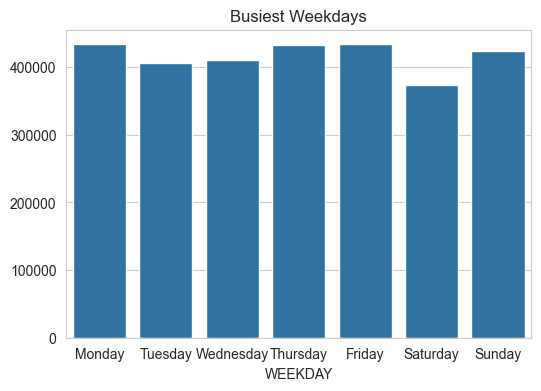

In [16]:
#Busiest Weekday

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts = active_flights['WEEKDAY'].value_counts().reindex(weekday_order)

plt.figure(figsize=(6,4))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
plt.title("Busiest Weekdays")
plt.show()

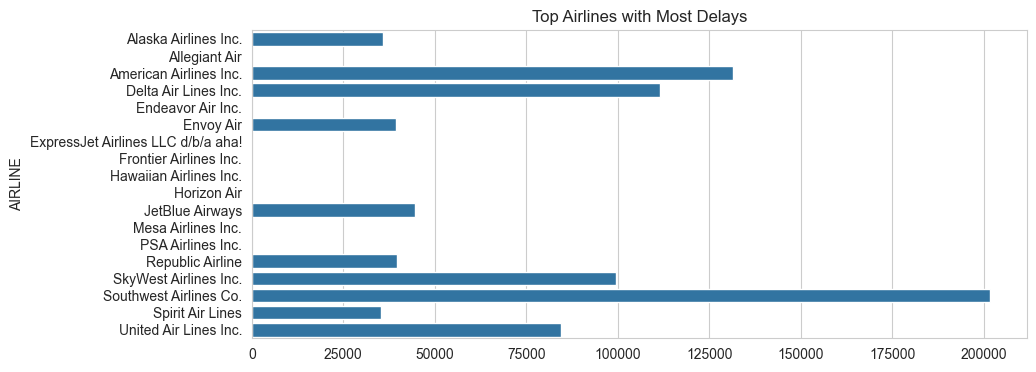

In [17]:
#Delay Analysis

delayed = active_flights[active_flights['ARR_DELAY'] > 0]

# Top Delayed Airlines
delayed_airlines = delayed['AIRLINE'].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=delayed_airlines.values, y=delayed_airlines.index)
plt.title("Top Airlines with Most Delays")
plt.show()

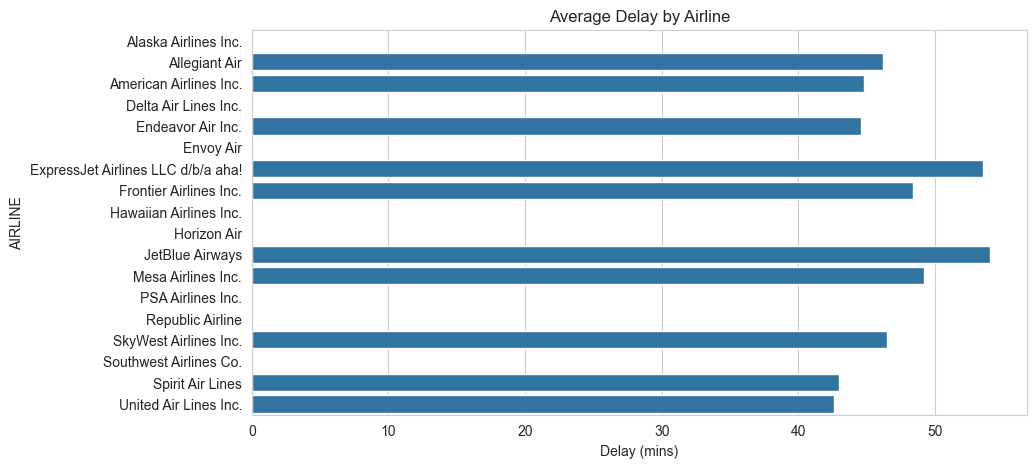

In [18]:
# Average Delay

avg_delay = delayed.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=avg_delay.values, y=avg_delay.index)
plt.title("Average Delay by Airline")
plt.xlabel("Delay (mins)")
plt.show()

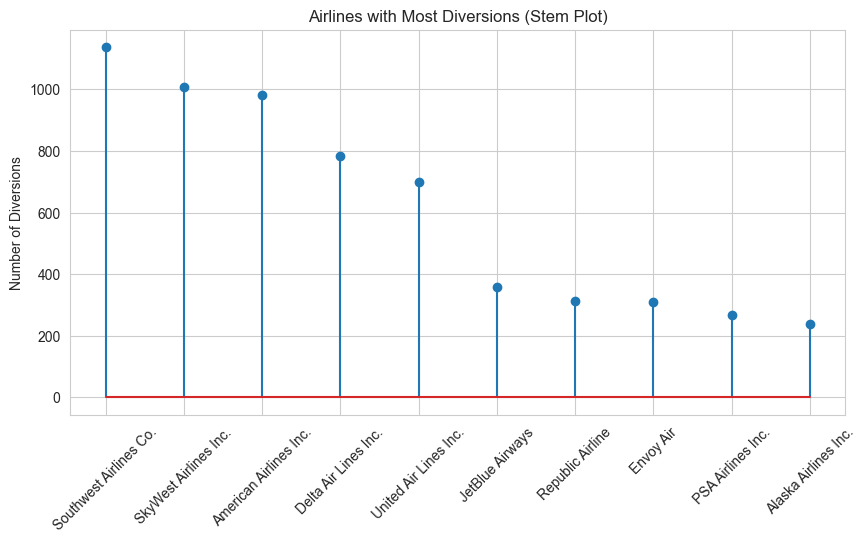

In [20]:
#Diversions (STEM PLOT)

diverted = df[df['DIVERTED'] == 1]['AIRLINE'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.stem(diverted.values)
plt.xticks(range(len(diverted.index)), diverted.index, rotation=45)
plt.title("Airlines with Most Diversions (Stem Plot)")
plt.ylabel("Number of Diversions")
plt.show()

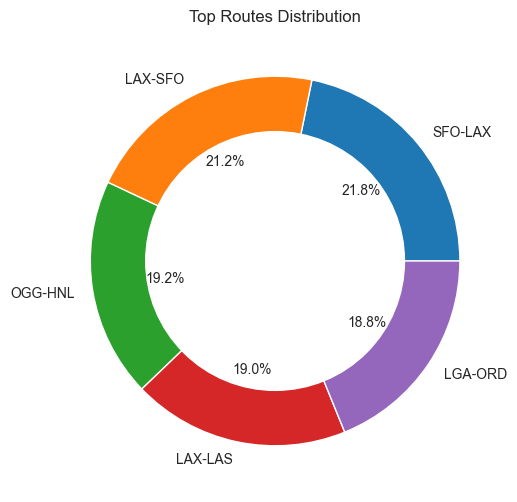

In [21]:
#Top Routes (DONUT CHART)

top_routes = active_flights['ROUTE'].value_counts().head(5)

plt.figure(figsize=(6,6))
plt.pie(top_routes.values, labels=top_routes.index, autopct='%1.1f%%')
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Top Routes Distribution")
plt.show()


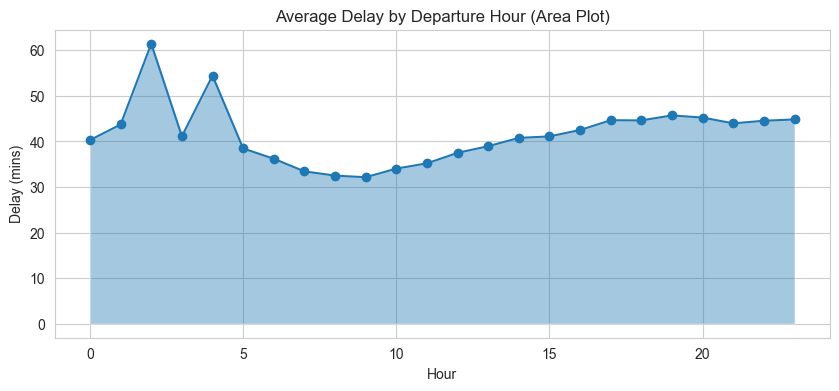

In [22]:
#Delay by Hour (AREA PLOT)

hour_delay = delayed.groupby('DEP_HOUR')['ARR_DELAY'].mean()

plt.figure(figsize=(10,4))
plt.fill_between(hour_delay.index, hour_delay.values, alpha=0.4)
plt.plot(hour_delay.index, hour_delay.values, marker='o')

plt.title("Average Delay by Departure Hour (Area Plot)")
plt.xlabel("Hour")
plt.ylabel("Delay (mins)")
plt.show()


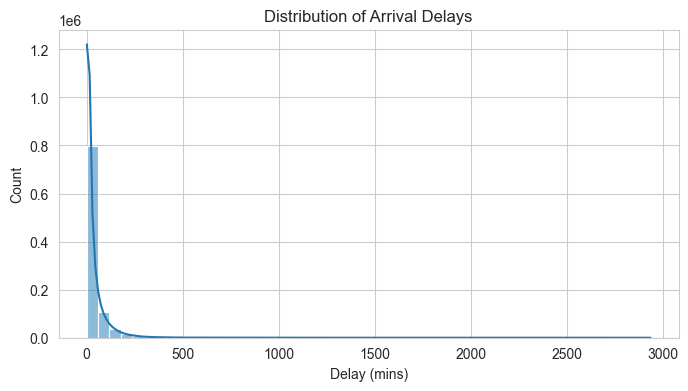

In [ ]:
#Delay Distribution 

plt.figure(figsize=(8,4))
sns.histplot(delayed['ARR_DELAY'], bins=50, kde=True)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Delay (mins)")
plt.show()